# Phase 4.5 — Weather Fusion Model Evaluation
Validates the weather-fusion improvement: test-set generalization check,
feature importance, and seasonal/hourly error breakdown (does Summer/Winter
error actually shrink, as predicted?).

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

DATA_DIR = "../data/processed"  # re-download train/val/test.parquet from S3 if you haven't already
# (these now include temp_f, hdd, cdd columns from the updated Glue job)

FEATURES = [
    "hour", "dayofweek", "month", "quarter", "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "dow_sin", "dow_cos",
    "lag_24h", "lag_168h", "rolling_mean_168h", "rolling_std_168h",
    "temp_f", "hdd", "cdd",
]
TARGET = "PJME_MW"

In [3]:
train = pd.read_parquet(f"{DATA_DIR}/train.parquet")
val = pd.read_parquet(f"{DATA_DIR}/val.parquet")
test = pd.read_parquet(f"{DATA_DIR}/test.parquet")

X_train, y_train = train[FEATURES], train[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

In [4]:
# ---- Retrain with weather features (same config as train_entry.py) ----
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="mae",
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

[0]	validation_0-mae:4780.78876
[50]	validation_0-mae:1364.22137
[100]	validation_0-mae:1141.82558
[150]	validation_0-mae:1094.58016
[200]	validation_0-mae:1072.71976
[250]	validation_0-mae:1062.16392
[300]	validation_0-mae:1057.30981
[350]	validation_0-mae:1053.55575
[400]	validation_0-mae:1051.39791
[414]	validation_0-mae:1051.89123


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=30,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

## 1. Val vs Test — check for overfitting

In [5]:
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

val_mae = mean_absolute_error(y_val, val_pred)
val_mape = mean_absolute_percentage_error(y_val, val_pred) * 100
test_mae = mean_absolute_error(y_test, test_pred)
test_mape = mean_absolute_percentage_error(y_test, test_pred) * 100

print(f"Val:  MAE={val_mae:.1f} MW, MAPE={val_mape:.2f}%")
print(f"Test: MAE={test_mae:.1f} MW, MAPE={test_mape:.2f}%")
print(f"\nGap: {abs(val_mape - test_mape):.2f} percentage points "
      f"({'looks healthy — similar generalization' if abs(val_mape - test_mape) < 1.5 else 'worth investigating — notable gap'})")

Val:  MAE=1051.4 MW, MAPE=3.39%
Test: MAE=1136.4 MW, MAPE=3.53%

Gap: 0.14 percentage points (looks healthy — similar generalization)


## 2. Feature importance — did weather actually earn its keep?

lag_24h              0.367491
cdd                  0.198795
lag_168h             0.093537
is_weekend           0.079036
temp_f               0.057173
hour                 0.042368
hdd                  0.034756
dayofweek            0.034731
is_holiday           0.016388
hour_cos             0.014294
dow_sin              0.013599
dow_cos              0.013452
hour_sin             0.012047
rolling_mean_168h    0.010165
month_cos            0.003619
rolling_std_168h     0.002753
month_sin            0.002205
month                0.002038
quarter              0.001552
dtype: float32

Combined weather feature importance: 0.291 (29.1% of total)


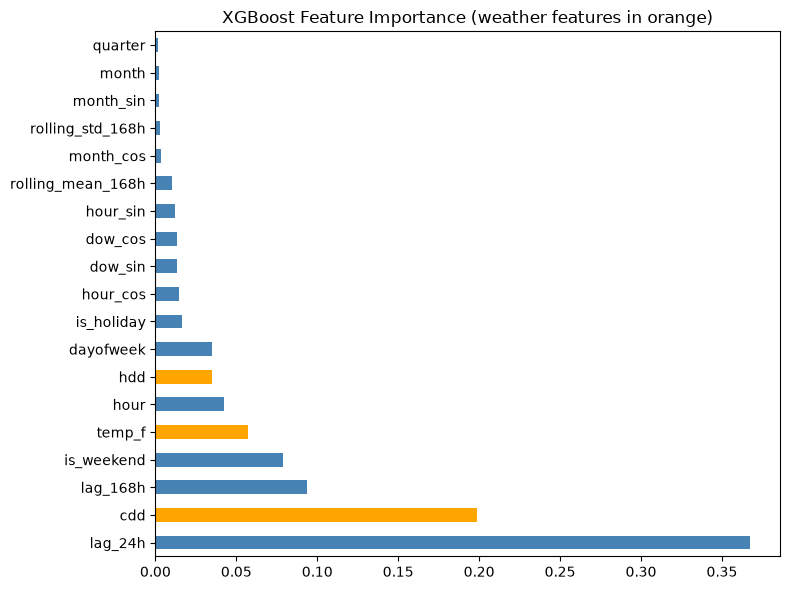

In [6]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importance)

weather_importance = importance[["temp_f", "hdd", "cdd"]].sum()
print(f"\nCombined weather feature importance: {weather_importance:.3f} "
      f"({weather_importance*100:.1f}% of total)")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["orange" if f in ["temp_f", "hdd", "cdd"] else "steelblue" for f in importance.index]
importance.plot(kind="barh", ax=ax, color=colors)
ax.set_title("XGBoost Feature Importance (weather features in orange)")
plt.tight_layout()
plt.savefig("../docs/feature_importance_with_weather.png", dpi=150)
plt.show()

## 3. Seasonal & hourly breakdown — the real test
Prediction to verify: Summer and Winter MAE should drop the most vs. the
pre-weather model (Summer was ~2,250 MW, Winter was ~1,850 MW previously).

In [7]:
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    else:
        return "Fall"

val_eval = val.copy()
val_eval["y_true"] = y_val
val_eval["y_pred"] = val_pred
val_eval["abs_err"] = (val_eval["y_true"] - val_eval["y_pred"]).abs()
val_eval["season"] = val_eval["month"].apply(month_to_season)

print("=== MAE by season (weather-fusion model) ===")
season_mae = val_eval.groupby("season")["abs_err"].mean().sort_values()
print(season_mae)
print("\nCompare against pre-weather model: Fall~1460, Spring~1530, Summer~2250, Winter~1850")

print("\n=== MAE by hour of day (weather-fusion model) ===")
hour_mae = val_eval.groupby("hour")["abs_err"].mean()
print(hour_mae)

=== MAE by season (weather-fusion model) ===
season
Winter     919.329719
Spring     949.127125
Fall      1028.163950
Summer    1305.657873
Name: abs_err, dtype: float64

Compare against pre-weather model: Fall~1460, Spring~1530, Summer~2250, Winter~1850

=== MAE by hour of day (weather-fusion model) ===
hour
0      748.296543
1      737.434011
2      701.369472
3      693.335025
4      714.612018
5      689.961173
6      748.074353
7      846.486301
8      941.193375
9      969.965577
10    1132.198924
11    1257.346484
12    1356.618804
13    1414.648673
14    1431.991829
15    1470.071281
16    1472.925193
17    1415.011478
18    1358.694467
19    1224.112034
20    1133.042541
21     969.895307
22     949.482374
23     854.936168
Name: abs_err, dtype: float64


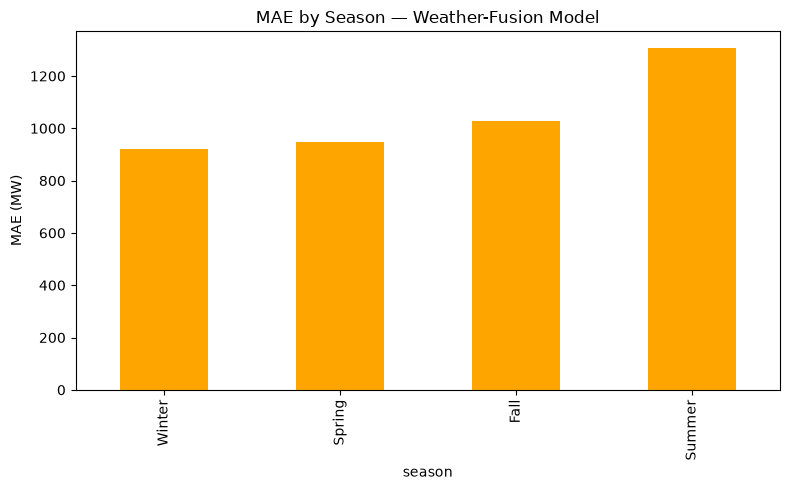

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
season_mae.plot(kind="bar", ax=ax, color="orange")
ax.set_title("MAE by Season — Weather-Fusion Model")
ax.set_ylabel("MAE (MW)")
plt.tight_layout()
plt.savefig("../docs/mae_by_season_weather_fusion.png", dpi=150)
plt.show()

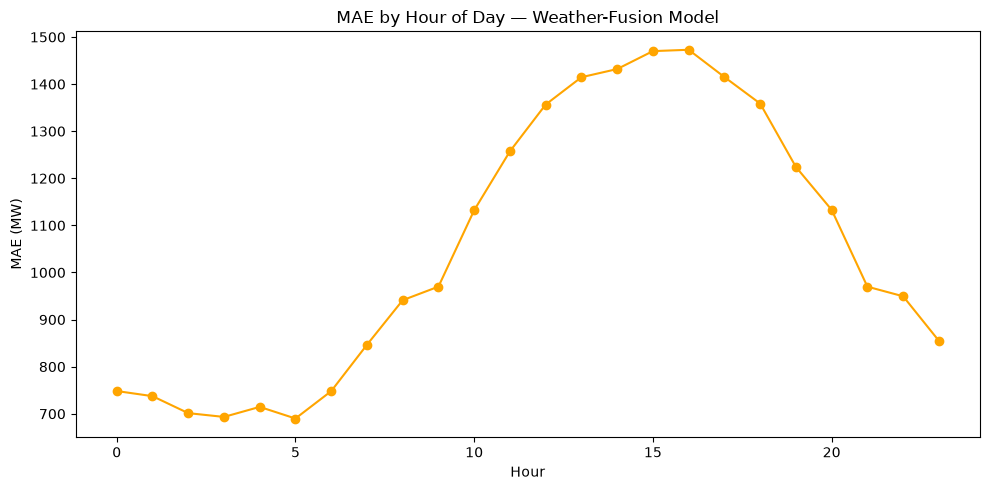

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
hour_mae.plot(ax=ax, marker="o", color="orange")
ax.set_title("MAE by Hour of Day — Weather-Fusion Model")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE (MW)")
plt.tight_layout()
plt.savefig("../docs/mae_by_hour_weather_fusion.png", dpi=150)
plt.show()